In [1]:
#Student Performance Analysis & Prediction

In [2]:

#IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:

#TASK 1 — DATA EXPLORATION


#Load dataset
df = pd.read_csv("students.csv")

# First 5 rows
print("First 5 rows:")
print(df.head())

#Shape and data types
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)

#Summary statistics
print("\nSummary Stats:\n", df.describe())

#Pass/Fail count
print("\nPass/Fail Count:\n", df['passed'].value_counts())

# Subject columns
subject_cols = ['math', 'science', 'english', 'history', 'pe']

#Average scores (Pass)
pass_avg = df[df['passed'] == 1][subject_cols].mean()
print("\nAverage scores (Pass):\n", pass_avg)

#Average scores (Fail)
fail_avg = df[df['passed'] == 0][subject_cols].mean()
print("\nAverage scores (Fail):\n", fail_avg)

#Highest overall average
df['overall_avg'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['overall_avg'].idxmax()]
print("\nTop Student:", top_student['name'], top_student['overall_avg'])


First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Stats:
             math    science    english    his

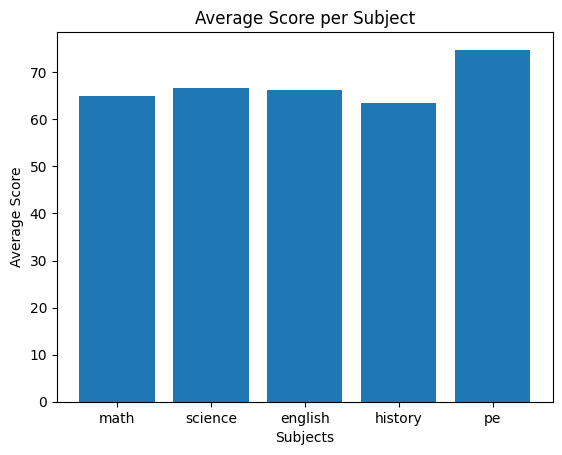

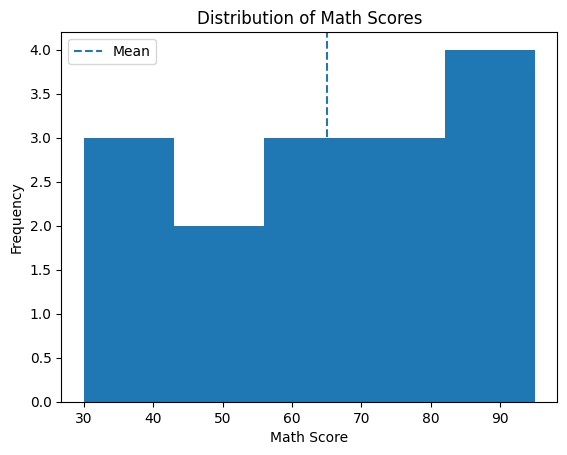

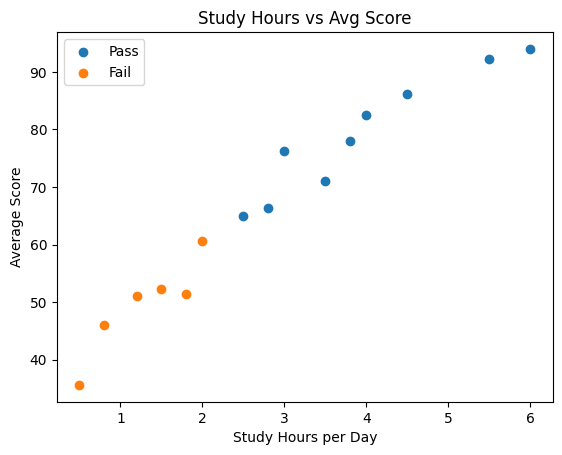

C:\Users\Pernytha\AppData\Local\Temp\ipykernel_3572\771539945.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


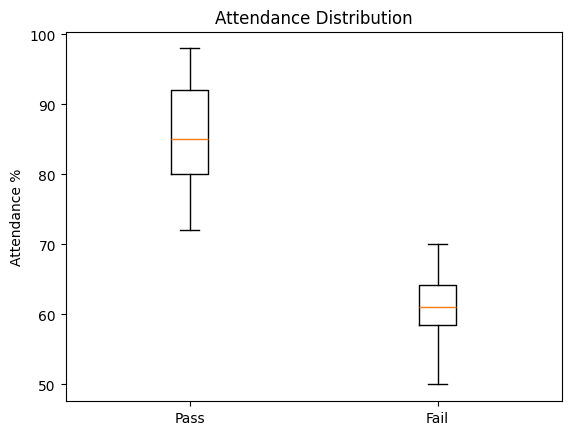

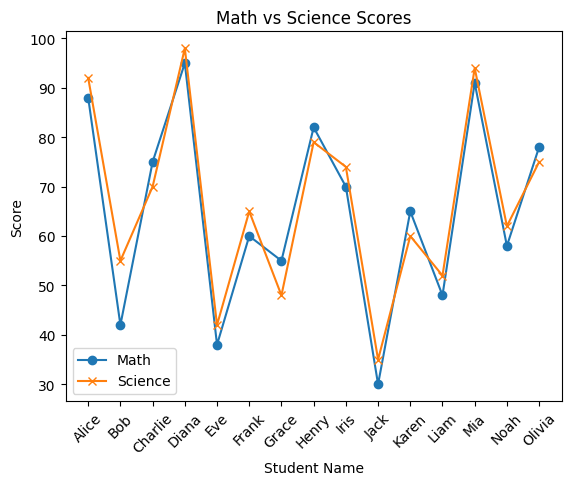

In [4]:

#TASK 2 — MATPLOTLIB


#Add avg_score column
df['avg_score'] = df[subject_cols].mean(axis=1)

#1. BAR CHART
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()


#2. HISTOGRAM 
mean_math = df['math'].mean()

plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(mean_math, linestyle='dashed', label='Mean')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()


#3. SCATTER 
plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.title("Study Hours vs Avg Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()


#4. BOX PLOT
pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']

plt.figure()
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()


#5. LINE PLOT 
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.title("Math vs Science Scores")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


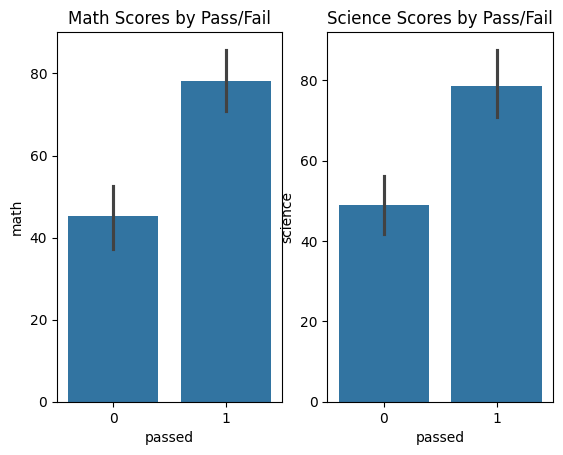

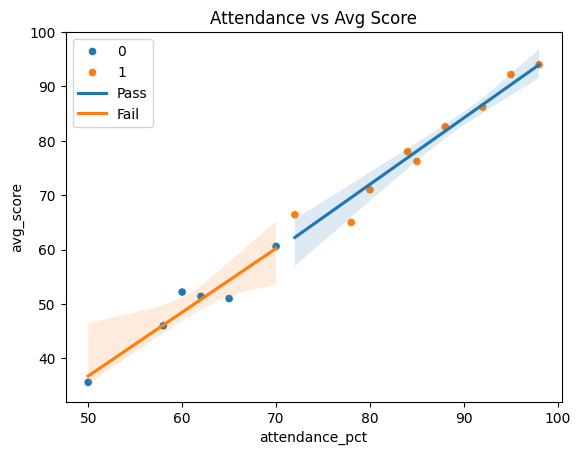

In [5]:

#TASK 3 — SEABORN


#6. SEABORN BAR
fig, (ax1, ax2) = plt.subplots(1, 2)

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Scores by Pass/Fail")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Scores by Pass/Fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()


#7. SEABORN SCATTER 
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Avg Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()





Training Accuracy: 1.0
Test Accuracy: 1.0

Predictions:
Jack Actual: 0 Pred: 0 ✅
Liam Actual: 0 Pred: 0 ✅
Alice Actual: 1 Pred: 1 ✅

Feature Importance:
english 0.8125127982724648
attendance_pct 0.521876340433209
study_hours_per_day 0.4844326627100155
pe 0.47497406284967797
math 0.43794393086873595
science 0.3230097624690249
history 0.26292892629062437


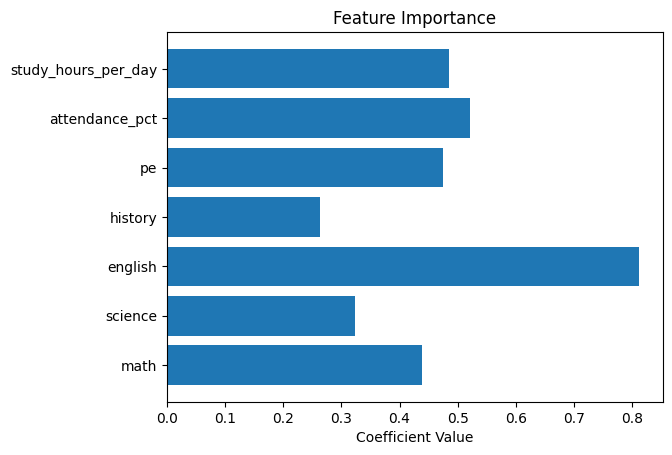

In [6]:

#TASK 4 — MACHINE LEARNING


#Features and target
features = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']

X = df[features]
y = df['passed']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#TRAIN MODEL
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("\nTraining Accuracy:", train_acc)


#EVALUATE
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

names = df.loc[X_test.index, 'name']

print("\nPredictions:")
for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅" if actual == pred else "❌"
    print(name, "Actual:", actual, "Pred:", pred, result)


#FEATURE IMPORTANCE 
coeffs = model.coef_[0]

feature_importance = sorted(
    zip(features, coeffs),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("\nFeature Importance:")
for f, c in feature_importance:
    print(f, c)

# Plot
plt.figure()

colors = ['green' if c > 0 else 'red' for c in coeffs]

plt.barh(features, coeffs)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")

plt.savefig("feature_importance.png")
plt.show()



